In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Driver parameters
theta1_0 = 65 * np.pi / 180
omega1 = np.pi
alpha1 = 0

# Time parameters
del_t = 0.01
t_end = 5.0
nsteps = int(t_end / del_t) + 1

# Initialize arrays
T = np.zeros(nsteps)
thetas = np.zeros((nsteps, 3))
thetas_d = np.zeros((nsteps, 3))
thetas_dd = np.zeros((nsteps, 3))


def s_rot(s):
    return np.array([-s[1], s[0]])

def kinematics(L1, L2):
    # First loop: Compute kinematics
    for i in range(nsteps):
        t = i * del_t
        T[i] = t
    
        # Driver link kinematics
        theta1 = theta1_0 + omega1 * t + 0.5 * alpha1 * t**2
        theta1_d = omega1 + alpha1 * t
        theta1_dd = alpha1
    
        theta2 = np.arcsin(-L1 * np.sin(theta1) / L2)
        theta3 = L1 * np.cos(theta1) + L2 * np.cos(theta2)
        u1 = np.array([np.cos(theta1), np.sin(theta1)])
        u2 = np.array([np.cos(theta2), np.sin(theta2)])
        u1r = s_rot(u1)
        u2r = s_rot(u2)
        C = np.column_stack((s_rot(u2) * L2, np.array([-1, 0])))
        rhsv = -L1 * u1r * theta1_d
        solution_v = np.linalg.solve(C, rhsv)
        theta2_d = solution_v[0]
        theta3_d = solution_v[1]
    
        rhsa = -L1 * u1r * theta1_dd + L1 * u1 * theta1_d**2 + L2 * u2 * theta2_d**2
        solution_a = np.linalg.solve(C, rhsa)
        theta2_dd = solution_a[0]
        theta3_dd = solution_a[1]
    
        thetas[i, :] = [theta1, theta2, theta3]
        thetas_d[i, :] = [theta1_d, theta2_d, theta3_d]
        thetas_dd[i, :] = [theta1_dd, theta2_dd, theta3_dd]

    
    # Dynamic Analysis
    # Mass and inertia parameters
    m1 = 1.0
    m2 = 1.5
    m3 = 0.0
    J1 = 0.001
    J2 = 0.002
    J3 = 1.0
    f3 = 40e3  # External force on link 3
    
    # Initialize arrays for results
    Lag = np.zeros((nsteps, 8))
    Torque1 = np.zeros(nsteps)
    Torque2 = np.zeros(nsteps)
    
    # Second loop: Compute dynamics
    for i in range(nsteps):
        theta = thetas[i, :]
        theta_d = thetas_d[i, :]
        theta_dd = thetas_dd[i, :]
    
        # Unit vectors
        c1 = np.cos(theta[0])
        s1 = np.sin(theta[0])
        c2 = np.cos(theta[1])
        s2 = np.sin(theta[1])
        u1 = np.array([c1, s1])
        u2 = np.array([c2, s2])
        u0 = np.array([1, 0])
        u1r = np.array([-s1, c1])
        u2r = np.array([-s2, c2])
        u0r = np.array([[0], [1]])  
    
        # Center of mass velocities
        rG1_d = 0.5 * L1 * u1r * theta_d[0]
        rG2_d = 2 * rG1_d + 0.5 * L2 * u2r * theta_d[1]
        rG3_d = u0 * theta_d[2]
    
        # Center of mass accelerations
        rG1_dd = 0.5 * L1 * (u1r * theta_dd[0] - u1 * theta_d[0]**2)
        rG2_dd = 2 * rG1_dd + 0.5 * L2 * (u2r * theta_dd[1] - u2 * theta_d[1]**2)
        rG3_dd = u0 * theta_dd[2]
    
        # Right-hand side vector (external forces and moments)
        rhs = np.hstack((
            m1 * rG1_dd,
            J1 * theta_dd[0],
            m2 * rG2_dd,
            J2 * theta_dd[1],
            m3 * rG3_dd - f3 * u0,
            0
        ))
    
        # Constraint force directions
        sO1r = -0.5 * L1 * u1r
        sA1r = -sO1r
        sA2r = -0.5 * L2 * u2r
        sB2r = -sA2r
    
        # Identity and zero matrices
        I22 = np.eye(2)
        Z22 = np.zeros((2, 2))
        Z12 = np.zeros((1, 2))
                
        # Constraint matrix
        Dt = np.block([
            [I22,  I22,  Z22,  Z22,  Z12.T],
            [sO1r.T, sA1r.T, Z12, Z12, np.array([[1]])],
            [Z22, -I22,  I22,  Z22,  Z12.T],
            [Z12, -sA2r.T, sB2r.T, Z12, np.array([[0]])],
            [Z22,  Z22, -I22, Z12.T, u0r, Z12.T],
            [Z12,  Z12,  Z12, np.array([[1]]), np.array([[0]]), np.array([[0]])]
        ])
        # Solve for constraint forces and torques
        sol = np.linalg.solve(Dt, rhs)
        Lag[i, :] = sol[:8]
        Torque1[i] = sol[8]
    
        # Array of body velocities
        c_d = np.hstack((
            rG1_d,
            theta_d[0],
            rG2_d,
            theta_d[1],
            rG3_d,
            0
        ))
    
        # Alternative torque calculation
        Torque2[i] = c_d @ rhs / theta_d[0]

    # Plot angular acceleration of link 3
    plt.figure(1)
    plt.plot(T, thetas_dd[:, 2])
    plt.xlabel('Time (s)')
    plt.ylabel('Angular Acceleration of Link 3 (rad/s^2)')
    plt.title('Angular Acceleration vs Time')
    plt.grid(True)
    plt.show()

    # Plot torque 
    plt.figure(1)
    plt.plot(T,Torque2)
    plt.xlabel('Time (s)')
    plt.ylabel('Torque (N*m)')
    plt.title(f'Torque over time with L1 = {L1} and L2 = {L2}')
    plt.grid(True)
    plt.show()

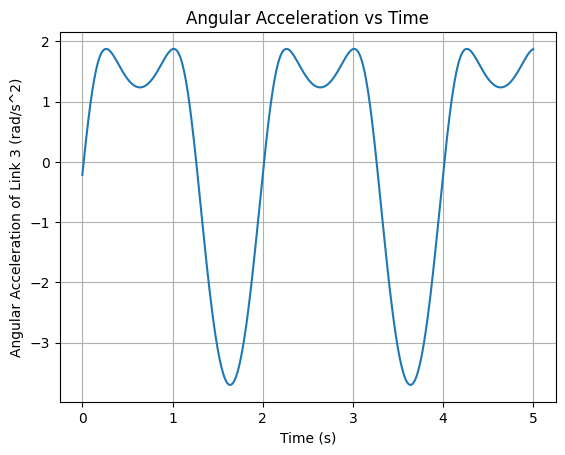

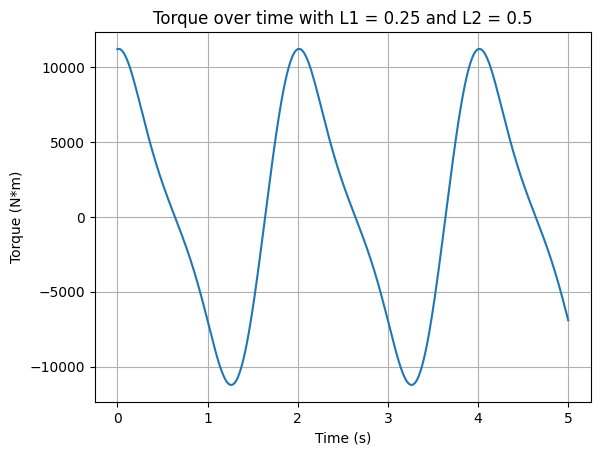

In [2]:
kinematics(0.25, 0.5)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle, Rectangle
import matplotlib.patches as patches
from IPython.display import HTML

# Add this magic command for Jupyter
%matplotlib notebook

# Driver parameters
theta1_0 = 65 * np.pi / 180
omega1 = np.pi
alpha1 = 0

# Time parameters
del_t = 0.02
t_end = 2
nsteps = int(t_end / del_t) + 1

# Initialize arrays
T = np.zeros(nsteps)
thetas = np.zeros((nsteps, 3))
thetas_d = np.zeros((nsteps, 3))
thetas_dd = np.zeros((nsteps, 3))

def s_rot(s):
    return np.array([-s[1], s[0]])

def kinematics(L1, L2):
    # First loop: Compute kinematics
    for i in range(nsteps):
        t = i * del_t
        T[i] = t
        
        # Driver link kinematics
        theta1 = theta1_0 + omega1 * t + 0.5 * alpha1 * t**2
        theta1_d = omega1 + alpha1 * t
        theta1_dd = alpha1
        
        theta2 = np.arcsin(-L1 * np.sin(theta1) / L2)
        theta3 = L1 * np.cos(theta1) + L2 * np.cos(theta2)
        
        u1 = np.array([np.cos(theta1), np.sin(theta1)])
        u2 = np.array([np.cos(theta2), np.sin(theta2)])
        u1r = s_rot(u1)
        u2r = s_rot(u2)
        
        C = np.column_stack((s_rot(u2) * L2, np.array([-1, 0])))
        rhsv = -L1 * u1r * theta1_d
        solution_v = np.linalg.solve(C, rhsv)
        theta2_d = solution_v[0]
        theta3_d = solution_v[1]
        
        rhsa = -L1 * u1r * theta1_dd + L1 * u1 * theta1_d**2 + L2 * u2 * theta2_d**2
        solution_a = np.linalg.solve(C, rhsa)
        theta2_dd = solution_a[0]
        theta3_dd = solution_a[1]
        
        thetas[i, :] = [theta1, theta2, theta3]
        thetas_d[i, :] = [theta1_d, theta2_d, theta3_d]
        thetas_dd[i, :] = [theta1_dd, theta2_dd, theta3_dd]

# Dynamic Analysis
# Mass and inertia parameters
m1 = 1.0
m2 = 1.5
m3 = 0.0
J1 = 0.001
J2 = 0.002
J3 = 1.0
f3 = 40e3  # External force on link 3

# Initialize arrays for results
Lag = np.zeros((nsteps, 8))
Torque1 = np.zeros(nsteps)
Torque2 = np.zeros(nsteps)

def dynamics(L1, L2):
    # Second loop: Compute dynamics
    for i in range(nsteps):
        theta = thetas[i, :]
        theta_d = thetas_d[i, :]
        theta_dd = thetas_dd[i, :]
        
        # Unit vectors
        c1 = np.cos(theta[0])
        s1 = np.sin(theta[0])
        c2 = np.cos(theta[1])
        s2 = np.sin(theta[1])
        u1 = np.array([c1, s1])
        u2 = np.array([c2, s2])
        u0 = np.array([1, 0])
        u1r = np.array([-s1, c1])
        u2r = np.array([-s2, c2])
        u0r = np.array([[0], [1]])
        
        # Center of mass velocities
        rG1_d = 0.5 * L1 * u1r * theta_d[0]
        rG2_d = 2 * rG1_d + 0.5 * L2 * u2r * theta_d[1]
        rG3_d = u0 * theta_d[2]
        
        # Center of mass accelerations
        rG1_dd = 0.5 * L1 * (u1r * theta_dd[0] - u1 * theta_d[0]**2)
        rG2_dd = 2 * rG1_dd + 0.5 * L2 * (u2r * theta_dd[1] - u2 * theta_d[1]**2)
        rG3_dd = u0 * theta_dd[2]
        
        # Right-hand side vector (external forces and moments)
        rhs = np.hstack((
            m1 * rG1_dd,
            J1 * theta_dd[0],
            m2 * rG2_dd,
            J2 * theta_dd[1],
            m3 * rG3_dd - f3 * u0,
            0
        ))
        
        # Constraint force directions
        sO1r = -0.5 * L1 * u1r
        sA1r = -sO1r
        sA2r = -0.5 * L2 * u2r
        sB2r = -sA2r
        
        # Identity and zero matrices
        I22 = np.eye(2)
        Z22 = np.zeros((2, 2))
        Z12 = np.zeros((1, 2))
        
        # Constraint matrix
        Dt = np.block([
            [I22, I22, Z22, Z22, Z12.T],
            [sO1r.T, sA1r.T, Z12, Z12, np.array([[1]])],
            [Z22, -I22, I22, Z22, Z12.T],
            [Z12, -sA2r.T, sB2r.T, Z12, np.array([[0]])],
            [Z22, Z22, -I22, Z12.T, u0r, Z12.T],
            [Z12, Z12, Z12, np.array([[1]]), np.array([[0]]), np.array([[0]])]
        ])
        
        # Solve for constraint forces and torques
        sol = np.linalg.solve(Dt, rhs)
        Lag[i, :] = sol[:8]
        Torque1[i] = sol[8]
        
        # Array of body velocities
        c_d = np.hstack((
            rG1_d, theta_d[0],
            rG2_d, theta_d[1],
            rG3_d, 0
        ))
        
        # Alternative torque calculation
        Torque2[i] = c_d @ rhs / theta_d[0]

# Set link lengths (you can adjust these)
L1 = 0.25  # Length of driver link (crank)
L2 = 0.5  # Length of connecting rod

# Run kinematics and dynamics
print("Computing kinematics...")
kinematics(L1, L2)
print("Computing dynamics...")
dynamics(L1, L2)
print("Creating animation...")

# Create animation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9))

# Setup the mechanism plot
ax1.set_xlim(-0.5, 1.2)
ax1.set_ylim(-0.8, 0.8)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('X Position (m)')
ax1.set_ylabel('Y Position (m)')
ax1.set_title('Slider-Crank Mechanism Animation')

# Initialize plot elements for mechanism
line1, = ax1.plot([], [], 'b-', linewidth=3, label='Crank (Link 1)')
line2, = ax1.plot([], [], 'r-', linewidth=3, label='Connecting Rod (Link 2)')
slider, = ax1.plot([], [], 'g-', linewidth=2, label='Slider')

# Joint circles
joint_O = Circle((0, 0), 0.02, color='black', zorder=5)
joint_A = Circle((0, 0), 0.02, color='black', zorder=5)
joint_B = Circle((0, 0), 0.02, color='black', zorder=5)
ax1.add_patch(joint_O)
ax1.add_patch(joint_A)
ax1.add_patch(joint_B)

# Ground representation
ground = Rectangle((-0.1, -0.05), 0.1, 0.05, color='gray', zorder=1)
ax1.add_patch(ground)

# Slider block
slider_block = Rectangle((0, -0.03), 0.06, 0.06, color='lightgreen', zorder=2)
ax1.add_patch(slider_block)

# Torque text
torque_text = ax1.text(-1.75, 0.75, '', fontsize=12, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
time_text = ax1.text(-1.75, 0.60, '', fontsize=10,
                     bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Setup torque plot
ax2.set_xlim(0, t_end)
ax2.set_ylim(np.min(Torque2)*1.1, np.max(Torque2)*1.1)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Torque (N·m)')
ax2.set_title('Input Torque vs Time')
ax2.grid(True, alpha=0.3)

# Torque line
torque_line, = ax2.plot([], [], 'b-', linewidth=2)
current_point, = ax2.plot([], [], 'ro', markersize=8)

ax1.legend(loc='upper right')

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    slider.set_data([], [])
    torque_line.set_data([], [])
    current_point.set_data([], [])
    return line1, line2, slider, torque_line, current_point, joint_O, joint_A, joint_B, slider_block, torque_text, time_text

def animate(frame):
    # Skip frames for smoother animation
    i = frame * 2
    if i >= nsteps:
        i = nsteps - 1
    
    theta1 = thetas[i, 0]
    theta2 = thetas[i, 1]
    theta3 = thetas[i, 2]
    
    # Joint positions
    O = np.array([0, 0])  # Fixed joint
    A = L1 * np.array([np.cos(theta1), np.sin(theta1)])  # End of crank
    B = np.array([theta3, 0])  # Slider position
    
    # Update links
    line1.set_data([O[0], A[0]], [O[1], A[1]])
    line2.set_data([A[0], B[0]], [A[1], B[1]])
    slider.set_data([B[0]-0.03, B[0]+0.03], [B[1], B[1]])
    
    # Update joint positions
    joint_O.center = O
    joint_A.center = A
    joint_B.center = B
    
    # Update slider block
    slider_block.set_x(B[0] - 0.03)
    
    # Update text
    torque_text.set_text(f'Torque: {Torque2[i]:.2f} N·m')
    time_text.set_text(f'Time: {T[i]:.2f} s')
    
    # Update torque plot
    torque_line.set_data(T[:i+1], Torque2[:i+1])
    current_point.set_data([T[i]], [Torque2[i]])
    
    return line1, line2, slider, torque_line, current_point, joint_O, joint_A, joint_B, slider_block, torque_text, time_text

# Create animation with fewer frames for better performance
frames = min(nsteps//2, 250)  # Limit frames for better performance
anim = animation.FuncAnimation(fig, animate, init_func=init,
                              frames=frames, interval=40, blit=True)

plt.tight_layout()

# Display the animation in Jupyter
display(HTML(anim.to_jshtml()))

# Alternative: Use this if the above doesn't work
# plt.show()

Computing kinematics...
Computing dynamics...
Creating animation...


<IPython.core.display.Javascript object>